<a href="https://colab.research.google.com/github/sebrew3/ANN-Vds-Symmetric-FET-Model_ECE-228/blob/main/ANN_IV_FET_MLP_ECE_228_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN-Based Drain-Source Symmetric FET Model
## Reproduction + Improvement: Multi-Gate-Length Extension

**Based on:** Xu et al., *"Drain-Source Symmetric Artificial Neural Network-Based FET Model with Robust Extrapolation Beyond Training Data"*, IEEE MTT-S 2007.

---

### README:
#### Overview

This notebook reproduces and extends the symmetric ANN-based FET model from Xu et al. (2007). The model learns to predict drain current Id from gate and drain voltages (Vgs, Vds) using a shared-weight neural network architecture that enforces exact drain-source symmetry by construction — meaning it accurately predicts Id-Vds behavior in both the positive and negative Vds regions while being trained only on Vds ≥ 0 data.

The main features of this notebook are as follows:

1. **Processes** Id-Vds data from the public MESD-MOSFET-Electrical-Simulation-Dataset (https://github.com/SJTU-YONGFU-RESEARCH-GRP/MESD-MOSFET-Electrical-Simulation-Dataset)
2. **Reproduces** Xu et al's symmetric ANN architecture using symmetric and anti-symmetric neural network formulations with applied symmetry constraints (Eq. 4-5 in the paper)
3. **Improves** the model by adding **multiple gate lengths (Lg)** as additional inputs; physics-based penalties that account for nanoscale short-channel effects are implemented in the training loop to capture how device scaling affects Id-Vds characteristics
4. **Validates** accurate symmetric device performance via Id-Vds family-of-curves plots, symmetry checks, and error analyses

#### Key Results

| | Paper (Xu et al. 2007) | This Notebook |
|---|---|---|
| **Architecture** | Symmetric + anti-symmetric ANN (MLP3/MLP4) | ✅ Symmetric ANN (tanh MLP, shared weights) |
| **Symmetry enforcement** | By construction via Eq. 4-5 | ✅ `ds_exchange()` + weight sharing |
| **Training data** | Measured GaAs pHEMT (Vds ≥ 0) | ✅ MESD BSIM-simulated MOSFET data (Vds ≥ 0 only) |
| **Symmetry error** | Guaranteed by construction | ✅ < 1e-5 mA (machine precision) |
| **Gate lengths** | Single (0.25µm) | 🆕 Multiple gate lengths (continuous Lg input) |
| **Saturation shaping** | Not discussed | 🆕 Physics augmentation + weighted loss |

#### Key Takeaways
1. **Symmetry** is guaranteed mathematically by the shared-weight ANN decomposition — the error is at floating-point precision (~1e-6), with no need for explicit symmetry constraints in the data.
2. **Gate-length extension** demonstrates that the ANN framework naturally accommodates an additional physical parameter as a third input, enabling a unified model across a device family — a practical improvement over single-device models.
3. **Physics-based augmentation and loss shaping** are effective tools for improving the fidelity of the mirrored negative-Vds curves without violating the paper's core constraint of training only on Vds ≥ 0.

#### Steps to Run Code and Reproduce Main Results

1. **Run Section 0** (Imports & Setup) to install and import all dependencies.
2. **Run Section 1** (Load MESD Dataset from GitHub) to download and unzip the MESD dataset directly from GitHub. Under the **Configuration** block in this section, you can customize:
   - `DEVICE_TYPE`: `'NMOS'` or `'PMOS'`
   - `CORNER`: process corner (default `'tt'` for typical-typical)
   - `TEMP`: measurement temperature in °C (default `-40`)
   - `TARGET_PDK`: which PDK to use for training (default `'N180A'` -- has the closest gate length to the 250nm used in the paper)
3. **Run Section 2** (Symmetric ANN Architecture + Training) to preprocess and augment the data, define the model, and train both the single-Lg and multi-Lg models. Training hyperparameters (epochs, learning rate, batch size) can be adjusted in the `train_model_weighted()` call at the bottom of this section.
4. **Run Section 3** (Symmetry Verification) to confirm that the model satisfies `Id(V) + Id(V-hat) = 0` to machine precision across the full voltage space.
5. **Run Section 4** (Id-Vds Curves) to reproduce the paper's Fig. 2 — the family of Id-Vds curves across all Vds (including negative), with and without the extrapolation routine.
6. **Run Section 5** (Multi-Gate-Length Curves) to view the improvement: Id-Vds curves predicted by the multi-Lg model across all gate lengths in the selected PDK.
7. **Run Section 6** (Quantitative Error Analysis) to compute MAE and R² on the held-out test set and view parity plots for both the single-Lg and multi-Lg models.

## 0. Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial import ConvexHull
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from itertools import product as iproduct
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load MESD Dataset from GitHub

The [MESD dataset](https://github.com/SJTU-YONGFU-RESEARCH-GRP/MESD-MOSFET-Electrical-Simulation-Dataset)
contains BSIM-simulated MOSFET I-V and C-V characteristics across:
- **Technology nodes**: 3 nm – 350 nm (11 PDKs, 44 device types)
- **Variables per record**: Vgs sweep, Ids, Cgg at fixed Vds, W, L, Nfin, Temp, Corner

The JSON structure is:
```
{PDK, Node, Device, Type, Simulator, Model,
 Record: [{Vgs:[...], Ids:[...], Vds, W, L, Nfin, Temp, Corner}, ...]}
```

**Our improvement**: use gate length `L` (nm) as an additional ANN input alongside
Vgs and Vds — enabling a single model to cover multiple technology dimensions.


In [ ]:
# ── Download and unzip MESD dataset directly from GitHub ─────────────────────
import os

!wget -q --show-progress https://github.com/SJTU-YONGFU-RESEARCH-GRP/MESD-MOSFET-Electrical-Simulation-Dataset/archive/refs/heads/main.zip -O MESD.zip
!unzip -q MESD.zip

MESD_DIR = '/content/MESD-MOSFET-Electrical-Simulation-Dataset-main/MESD'
json_files = sorted([f for f in os.listdir(MESD_DIR) if f.endswith('.json')])
print(f"Found {len(json_files)} JSON files")

MESD.zip                [         <=>        ] 122.43M  5.73MB/s    in 23s     
Found 44 JSON files


In [ ]:
import json, os

# Peek at the contents of one JSON file to see the actual field values
sample_file = os.path.join(MESD_DIR, json_files[0])
with open(sample_file) as f:
    data = json.load(f)

print("Type:", data.get('Type'))
print("Keys:", list(data.keys()))
print("\nFirst record keys:", list(data['Records'][0].keys()))
print("First record (non-list fields):")
for k, v in data['Records'][0].items():
    if not isinstance(v, list):
        print(f"  {k}: {repr(v)}")

Type: NMOS
Keys: ['PDK', 'Node', 'Model', 'Device', 'Type', 'Simulator', 'Records']

First record keys: ['Nfin', 'L', 'Corner', 'Temp', 'Vds', 'Vgs', 'Ids', 'Cgg']
First record (non-list fields):
  Nfin: 1
  L: 15
  Corner: 'tt'
  Temp: -40
  Vds: 0.0


In [ ]:
import json, os
import numpy as np
import pandas as pd

# ── Configuration ─────────────────────────────────────────────────────────────
DEVICE_TYPE  = 'NMOS'        # 'NMOS' or 'PMOS'
CORNER       = 'tt'          # process corner to use (typical-typical)
TEMP         = -40            # temperature in °C
# Gate lengths (L in nm) to include in the multi-L improvement.
# These must exist in the dataset; we select a representative spread.
L_WHITELIST  = None          # set to e.g. [45, 90, 180, 350] to restrict, or None for all

# ── Parse all JSON files ──────────────────────────────────────────────────────
records = []

for fname in json_files:
    fpath = os.path.join(MESD_DIR, fname)
    with open(fpath) as f:
        data = json.load(f)

    if data.get('Type', '').upper() != DEVICE_TYPE:
        continue

    pdk  = data.get('PDK', fname)
    node = data.get('Node', None)   # technology node in nm

    for rec in data.get('Records', []):
        # Filter on corner and temperature
        if rec.get('Corner', 'tt') != CORNER:
            continue
        if rec.get('Temp', 27) != TEMP:
            continue

        L    = rec.get('L',    None)   # gate length in nm
        W    = rec.get('W',    None)   # width in nm
        Nfin = rec.get('Nfin', 1)     # number of fingers (1 for planar)
        Vds  = rec.get('Vds',  None)
        Vgs_list = rec.get('Vgs', [])
        Ids_list = rec.get('Ids', [])

        if L is None or Vds is None or len(Vgs_list) == 0:
            continue
        if L_WHITELIST is not None and L not in L_WHITELIST:
            continue

        for vgs, ids in zip(Vgs_list, Ids_list):
            records.append({
                'PDK':  pdk,
                'Node': node,
                'L_nm': L,
                'W_nm': W,
                'Nfin': Nfin,
                'Vgs':  float(vgs),
                'Vds':  float(Vds),
                'Ids': float(ids),
            })

df_raw = pd.DataFrame(records)

# Convert Ids to mA for numerics (consistent with paper's units)
df_raw['Ids_mA'] = df_raw['Ids'] * 1e3

print(f"Total records parsed : {len(df_raw):,}")
print(f"Unique gate lengths L: {[int(x) for x in sorted(df_raw['L_nm'].unique())]} nm")
print(f"Unique Vds values : {[float(x) for x in sorted(df_raw['Vds'].unique())]}")
print(f"Vgs range            : {df_raw['Vgs'].min():.3f} – {df_raw['Vgs'].max():.3f} V")
print(f"Ids range (mA)       : {df_raw['Ids_mA'].min():.4f} – {df_raw['Ids_mA'].max():.4f}")
df_raw.head(8)


Total records parsed : 153,105
Unique gate lengths L: [15, 40, 45, 60, 64, 82, 90, 95, 112, 118, 127, 137, 153, 154, 179, 180, 201, 210, 228, 252, 262, 286, 304, 312, 343, 350, 356, 391, 448, 502, 513, 535, 543, 586, 600, 656, 709, 711, 732, 765, 865, 886, 1000, 1230, 1295, 1308, 1460, 1622, 1931, 2305, 2465, 2851, 3089, 3699, 4160, 4209, 4321, 6214, 7021, 7368, 8100, 8434, 9175, 11850, 13546, 15183, 17575, 19232, 20000, 28460, 41923, 43855, 53348, 100000] nm
Unique Vds values : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 1.6, 1.8, 2.0, 2.1, 2.4, 2.7, 3.0, 3.3, 4.0, 5.0]
Vgs range            : 0.000 – 5.000 V
Ids range (mA)       : -0.0113 – 97.5820


,PDK,Node,L_nm,W_nm,Nfin,Vgs,Vds,Ids,Ids_mA
0,N15A,15,15,NaN,1,0.0,0.0,0.000000e+00,0.000000e+00
1,N15A,15,15,NaN,1,0.1,0.0,-1.299200e-17,-1.299200e-14
2,N15A,15,15,NaN,1,0.2,0.0,-1.487500e-15,-1.487500e-12
3,N15A,15,15,NaN,1,0.3,0.0,-6.842400e-14,-6.842400e-11
4,N15A,15,15,NaN,1,0.4,0.0,-4.805200e-13,-4.805200e-10
5,N15A,15,15,NaN,1,0.5,0.0,-1.411800e-12,-1.411800e-09
6,N15A,15,15,NaN,1,0.6,0.0,-2.967600e-12,-2.967600e-09
7,N15A,15,15,NaN,1,0.7,0.0,-5.265600e-12,-5.265600e-09


In [ ]:
# ── Preprocessing & train/test split ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

df_train_pool = df_raw[df_raw['Vds'] >= 0].copy()

TARGET_PDK = 'N180A'
df_pdk = df_train_pool[df_train_pool['PDK'] == TARGET_PDK]

# Filter data to only use data points with the same number of fingers and width
# Allows for proper training of model with only relevant data
L_paper  = int(df_pdk['L_nm'].min())
W_sel    = int(df_pdk[df_pdk['L_nm'] == L_paper]['W_nm'].max())
Nfin_sel = 1
print(f"Using PDK={TARGET_PDK}, L={L_paper}nm, W={W_sel}nm, Nfin={Nfin_sel}")

df_single = df_pdk[
    (df_pdk['L_nm'] == L_paper) &
    (df_pdk['W_nm'] == W_sel)   &
    (df_pdk['Nfin'] == Nfin_sel)
].copy()

print(f"  Vgs range : {df_single['Vgs'].min():.3f} – {df_single['Vgs'].max():.3f} V")
print(f"  Vds range : {df_single['Vds'].min():.3f} – {df_single['Vds'].max():.3f} V")
print(f"  Ids range : {df_single['Ids_mA'].min():.4f} – {df_single['Ids_mA'].max():.4f} mA")

X_single = df_single[['Vgs', 'Vds']].values.astype(np.float32)
y_single = df_single[['Ids_mA']].values.astype(np.float32)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_single, y_single, test_size=0.15, random_state=42)
print(f"Single-L train: {len(X_tr_s):,}  |  test: {len(X_te_s):,}")

# ── Multi-L: span sub-180nm nodes by normalizing Ids per device ──────────────
TARGET_PDKS = ['N15A', 'N45A', 'N90A', 'N180A']
Nfin_sel    = 1

rows      = []
scale_map = {}
seen_L    = set()  # ensures each gate length appears exactly once

for pdk in TARGET_PDKS:
    df_pdk_m = df_train_pool[
        (df_train_pool['PDK']  == pdk) &
        (df_train_pool['Nfin'] == Nfin_sel)
    ]
    for L_nm in sorted(df_pdk_m['L_nm'].unique()):
        if L_nm in seen_L:      # skip if this L is already added from an earlier PDK
            continue
        df_L = df_pdk_m[df_pdk_m['L_nm'] == L_nm]
        W_available = df_L['W_nm'].dropna().unique()
        if len(W_available) == 0:
            continue
        W_use  = int(max(W_available))
        df_dev = df_L[df_L['W_nm'] == W_use].copy()

        ids_min = df_dev['Ids_mA'].min()
        ids_max = df_dev['Ids_mA'].max()
        if ids_max - ids_min < 1e-6:
            continue

        df_dev['Ids_norm'] = (df_dev['Ids_mA'] - ids_min) / (ids_max - ids_min)
        vgs_max = df_dev['Vgs'].max()
        vds_max = df_dev['Vds'].max()
        df_dev['Vgs_norm'] = df_dev['Vgs'] / vgs_max
        df_dev['Vds_norm'] = df_dev['Vds'] / vds_max

        scale_map[(pdk, int(L_nm))] = {
            'ids_min': ids_min, 'ids_max': ids_max,
            'vgs_max': vgs_max, 'vds_max': vds_max,
            'W_nm': W_use, 'PDK': pdk
        }
        rows.append(df_dev)
        seen_L.add(L_nm)        # mark this L as taken

df_multi_pool = pd.concat(rows).copy()

L_min = df_multi_pool['L_nm'].min()
L_max = df_multi_pool['L_nm'].max()
df_multi_pool['L_norm'] = (df_multi_pool['L_nm'] - L_min) / (L_max - L_min + 1e-9)

X_multi = df_multi_pool[['Vgs_norm', 'Vds_norm', 'L_norm']].values.astype(np.float32)
y_multi = df_multi_pool[['Ids_norm']].values.astype(np.float32)

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_multi, y_multi, test_size=0.15, random_state=42)
print(f"Multi-L  train: {len(X_tr_m):,}  |  test: {len(X_te_m):,}")

L_vals_nm   = sorted(df_multi_pool['L_nm'].unique())
L_norm_vals = [(L - L_min) / (L_max - L_min + 1e-9) for L in L_vals_nm]
print(f"\nGate lengths: {[int(x) for x in L_vals_nm]} nm")
print(f"PDKs included: {df_multi_pool['PDK'].unique()}")
print("\nOne device per L — scale map:")
for (pdk, L), s in sorted(scale_map.items(), key=lambda x: x[0][1]):
    print(f"  L={L}nm  PDK={pdk}  W={s['W_nm']}nm | "
          f"Vgs_max={s['vgs_max']:.2f}V  Vds_max={s['vds_max']:.2f}V | "
          f"Ids: {s['ids_min']:.3f}–{s['ids_max']:.3f} mA")


Using PDK=N180A, L=180nm, W=100000nm, Nfin=1
  Vgs range : 0.000 – 1.800 V
  Vds range : 0.000 – 2.100 V
  Ids range : -0.0000 – 66.6380 mA
Single-L train: 129  |  test: 23
Multi-L  train: 3,607  |  test: 637

Gate lengths: [45, 64, 90, 118, 127, 154, 179, 180, 201, 252, 262, 304, 343, 356, 448, 502, 513, 586, 709, 765, 865, 1000, 1460, 2465, 4160, 7021, 11850, 20000] nm
PDKs included: ['N45A' 'N90A' 'N180A']

One device per L — scale map:
  L=45nm  PDK=N45A  W=1000nm | Vgs_max=1.00V  Vds_max=1.00V | Ids: -0.000–1.360 mA
  L=64nm  PDK=N45A  W=1000nm | Vgs_max=1.00V  Vds_max=1.00V | Ids: -0.000–1.136 mA
  L=90nm  PDK=N45A  W=1000nm | Vgs_max=1.00V  Vds_max=1.00V | Ids: -0.000–1.074 mA
  L=118nm  PDK=N90A  W=1000nm | Vgs_max=2.00V  Vds_max=2.00V | Ids: -0.000–1.066 mA
  L=127nm  PDK=N45A  W=1000nm | Vgs_max=1.00V  Vds_max=1.00V | Ids: -0.000–1.036 mA
  L=154nm  PDK=N90A  W=1000nm | Vgs_max=2.00V  Vds_max=2.00V | Ids: -0.000–0.926 mA
  L=179nm  PDK=N45A  W=1000nm | Vgs_max=1.00V  Vds_max=

## 2. Symmetric ANN Architecture

Following Section III-IV of the paper, we decompose the constitutive relations into **symmetric** and **anti-symmetric** components:

$$F_{\text{sym}}(V) = f_{\text{ANN}}(V) + f_{\text{ANN}}(\hat{V})$$
$$F_{\text{anti}}(V) = f_{\text{ANN}}(V) - f_{\text{ANN}}(\hat{V})$$

where $\hat{V} = [V_{gs} - V_{ds}, -V_{ds}]$ is the drain-source exchanged operating point.

The drain current is then:
$$I_d^{dc}(V) = F_{\text{anti}}(V) - \tfrac{1}{2} F_{\text{sym}}(V)$$

This guarantees exact symmetry by construction — no extra regularization needed.

In [ ]:
class BaseMLP(nn.Module):
    # Core MLP (fANN in the paper). Used as building block for symmetric/anti-symmetric networks.
    def __init__(self, input_dim=2, hidden_dims=(32, 32), output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.Tanh())  # tanh ensures infinite differentiability (key paper claim)
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def ds_exchange(V, has_Lg=False):
    """
    Apply drain-source exchange transformation to input voltage vector.

    For V = [Vgs, Vds]:  V_hat = [Vgs - Vds, -Vds]   (i.e., Vgd, -Vds)
    For V = [Vgs, Vds, Lg]: transform Vgs/Vds only; Lg is invariant under DS exchange.
    """
    if has_Lg:
        Vgs = V[:, 0:1]
        Vds = V[:, 1:2]
        Lg  = V[:, 2:3]
        Vgd = Vgs - Vds
        return torch.cat([Vgd, -Vds, Lg], dim=1)
    else:
        Vgs = V[:, 0:1]
        Vds = V[:, 1:2]
        Vgd = Vgs - Vds
        return torch.cat([Vgd, -Vds], dim=1)


class SymmetricANNFET(nn.Module):
    """
    Symmetric ANN FET model (paper Eq. 4-5).

    Uses shared-weight symmetric/anti-symmetric decomposition (seen in text box above):
        F_sym  = f(V) + f(V_hat)
        F_anti = f(V) - f(V_hat)
        Id     = F_anti - 0.5 * F_sym  (from paper Eq. 4, bottom row for Qd, adapted for Id)

    The shared weights ensure exact symmetry by construction.
    """
    def __init__(self, input_dim=2, hidden_dims=(32, 32), has_Lg=False):
        super().__init__()
        self.has_Lg = has_Lg
        self.f_ann = BaseMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=1)

    def forward(self, V):
        V_hat = ds_exchange(V, has_Lg=self.has_Lg)
        f_V     = self.f_ann(V)
        f_V_hat = self.f_ann(V_hat)
        F_sym  = f_V + f_V_hat          # symmetric component
        F_anti = f_V - f_V_hat          # anti-symmetric component
        # Id^dc = F_anti_Id - 0.5 * F_sym_Ig   (Eq. 4 in paper)
        # For DC drain current we model it as: F_anti (dominant) - 0.5 * F_sym
        Id = F_anti - 0.5 * F_sym
        return Id

    def check_symmetry(self, V):
        # Verify Id(V) = -Id(V_hat) up to numerical precision.
        V_hat = ds_exchange(V, has_Lg=self.has_Lg)
        Id_V     = self.forward(V)
        Id_V_hat = self.forward(V_hat)
        return torch.max(torch.abs(Id_V + Id_V_hat)).item()


print("Architecture defined.")

# ── Model summary ─────────────────────────────────────────────────────────────
model_single = SymmetricANNFET(input_dim=2, hidden_dims=(32, 32), has_Lg=False).to(device)
total_params = sum(p.numel() for p in model_single.parameters())
print(f"Single-Lg model parameters: {total_params}")

model_multi = SymmetricANNFET(input_dim=3, hidden_dims=(48, 48), has_Lg=True).to(device)
total_params_multi = sum(p.numel() for p in model_multi.parameters())
print(f"Multi-Lg  model parameters: {total_params_multi}")

Architecture defined.
Single-Lg model parameters: 1185
Multi-Lg  model parameters: 2593


In [ ]:
def physics_penalty(model, X_batch, device, has_Lg=False):
    """
    Physics-based penalty terms for short-channel effects.

    Three penalties enforced via autograd:

    1. Monotonicity: Id should be non-decreasing with Vgs
       (dId/dVgs >= 0). Short-channel devices can violate this
       near threshold — penalize any negative gradient.

    2. Saturation: dId/dVds should decrease as Vds increases
       (d^2Id/dVds^2 <= 0 in saturation). Enforces the current
       flattening behavior expected beyond the knee voltage.

    3. Threshold (short-channel specific): At Vgs=0 (normalized),
       Id should be ~0. Short-channel leakage violates this —
       penalize any positive current at zero gate bias.
    """
    X = X_batch.clone().requires_grad_(True)

    Id = model(X)

    # ── Penalty 1: dId/dVgs >= 0 (Monotonic Transconductance) ─────────────────
    grad_all = torch.autograd.grad(
        Id.sum(), X, create_graph=True, retain_graph=True
    )[0]
    dId_dVgs = grad_all[:, 0]                          # column 0 = Vgs
    penalty_gm = torch.relu(-dId_dVgs).pow(2).mean()   # penalise negative gm

    # ── Penalty 2: d^2Id/dVds^2 <= 0 (Saturation Curvature) ─────────────────────
    dId_dVds = grad_all[:, 1]                          # column 1 = Vds
    # Second derivative via grad of first derivative
    d2Id_dVds2 = torch.autograd.grad(
        dId_dVds.sum(), X, create_graph=False, retain_graph=True
    )[0][:, 1]
    penalty_sat = torch.relu(d2Id_dVds2).pow(2).mean() # penalise positive curvature

    # ── Penalty 3: Id(Vgs=0) ~ 0 (Subthreshold Leakage) ───────────────────────
    # Build a mini-batch with Vgs forced to 0, same Vds (and L) as batch
    X_zero_vgs = X_batch.clone()
    X_zero_vgs[:, 0] = 0.0                             # set normalised Vgs = 0
    Id_at_zero_vgs = model(X_zero_vgs)
    penalty_leak = torch.relu(Id_at_zero_vgs).pow(2).mean()

    return penalty_gm, penalty_sat, penalty_leak


########## ────────────────── MAIN TRAINING LOOP ────────────────── ##########
def train_model_weighted(model, X_train, y_train, epochs, lr, batch_size,
                         sym_weight=0.1,
                         lambda_gm=0.05,    # weight for gm monotonicity penalty
                         lambda_sat=0.05,   # weight for saturation curvature penalty
                         lambda_leak=0.02,  # weight for zero-Vgs leakage penalty
                         verbose=True):
    """
    Loss = MSE (saturation-weighted)
         + sym_weight    *  symmetry regulariser
         + lambda_gm     *  gm monotonicity penalty       (short-channel effect 1)
         + lambda_sat    *  saturation curvature penalty  (short-channel effect 2)
         + lambda_leak   *  subthreshold leakage penalty  (short-channel effect 3)
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )

    X_abs_max = np.abs(X_train).max(axis=0)
    X_abs_max[X_abs_max == 0] = 1e-9
    X_train_norm = X_train / X_abs_max

    y_min, y_max = y_train.min(), y_train.max()
    y_scl = y_max - y_min
    if y_scl == 0:
        y_scl = 1e-9
    y_train_norm = (y_train - y_min) / y_scl

    train_dataset = TensorDataset(torch.from_numpy(X_train_norm).float(),
                                  torch.from_numpy(y_train_norm).float())
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    loss_history        = []
    penalty_history_gm  = []
    penalty_history_sat = []
    penalty_history_leak= []

    for epoch in range(epochs):
        model.train()
        epoch_mse = epoch_gm = epoch_sat = epoch_leak = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            # ── Main MSE loss (saturation-weighted) ───────────────────────
            outputs  = model(X_batch)
            Vds_col  = X_batch[:, 1]
            weights  = torch.where(Vds_col > 0.5,
                                   torch.full_like(Vds_col, 3.0),
                                   torch.ones_like(Vds_col)) # Vds > 0.5 roughly defines the saturation region
            mse_loss = ((outputs - y_batch).pow(2) * weights.unsqueeze(1)).mean()

            # ── Symmetry regularizer ──────────────────────────────────────
            V_hat    = ds_exchange(X_batch, has_Lg=model.has_Lg)
            Id_hat   = model(V_hat)
            sym_loss = (outputs + Id_hat).pow(2).mean()

            # ── Physics penalties ─────────────────────────────────────────
            p_gm, p_sat, p_leak = physics_penalty(
                model, X_batch, device, has_Lg=model.has_Lg
            )

            total_loss = (mse_loss
                          + sym_weight   * sym_loss
                          + lambda_gm   * p_gm
                          + lambda_sat  * p_sat
                          + lambda_leak * p_leak) # Combines all weighted loss terms * penalties

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_mse  += mse_loss.item()
            epoch_gm   += p_gm.item()
            epoch_sat  += p_sat.item()
            epoch_leak += p_leak.item()

        scheduler.step()
        n_batches = len(train_loader)
        loss_history.append(epoch_mse / n_batches)
        penalty_history_gm.append(epoch_gm   / n_batches)
        penalty_history_sat.append(epoch_sat  / n_batches)
        penalty_history_leak.append(epoch_leak/ n_batches)

        if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1:4d}/{epochs} | "
                  f"MSE: {loss_history[-1]:.5f} | "
                  f"gm: {penalty_history_gm[-1]:.5f} | "
                  f"sat: {penalty_history_sat[-1]:.5f} | "
                  f"leak: {penalty_history_leak[-1]:.5f}")

    # Store penalty histories on model for later plotting
    model.penalty_history_gm   = penalty_history_gm
    model.penalty_history_sat  = penalty_history_sat
    model.penalty_history_leak = penalty_history_leak

    return loss_history, np.zeros_like(X_abs_max), X_abs_max, X_abs_max, y_scl

def predict(model, X_in, X_min, X_rng, y_scl):
    # X_min will be zeros, X_rng will be X_abs_max, so this is just X / X_abs_max
    model.eval()
    with torch.no_grad():
        X_norm = X_in / X_rng         # symmetric division, same as training
        X_tensor = torch.from_numpy(X_norm.astype(np.float32)).to(device)
        predictions_norm = model(X_tensor).cpu().numpy()
        predictions = predictions_norm * y_scl
    return predictions

# ── Single Length Input Model ─────────────────────────────────────────────────
print("Training single-L model (paper reproduction)...")
model_single = SymmetricANNFET(input_dim=2, hidden_dims=(32, 32), has_Lg=False).to(device)
loss_hist_single, Xmin_s, Xmax_s, Xrng_s, yscl_s = train_model_weighted(
    model_single, X_tr_s, y_tr_s,
    epochs=3000, lr=1e-3, batch_size=512, sym_weight=0.1, verbose=True
)
print("Single-L model training complete.")

Training single-L model (paper reproduction)...
Epoch    1/3000 | MSE: 0.37362 | gm: 0.01283 | sat: 0.00012 | leak: 0.01086
Epoch  301/3000 | MSE: 0.01035 | gm: 0.00084 | sat: 0.07113 | leak: 0.00000
Epoch  601/3000 | MSE: 0.00186 | gm: 0.00124 | sat: 0.08307 | leak: 0.00000
Epoch  901/3000 | MSE: 0.00148 | gm: 0.00156 | sat: 0.08845 | leak: 0.00001
Epoch 1201/3000 | MSE: 0.00116 | gm: 0.00114 | sat: 0.06872 | leak: 0.00001
Epoch 1501/3000 | MSE: 0.00089 | gm: 0.00074 | sat: 0.05722 | leak: 0.00001
Epoch 1801/3000 | MSE: 0.00072 | gm: 0.00056 | sat: 0.05548 | leak: 0.00001
Epoch 2101/3000 | MSE: 0.00063 | gm: 0.00048 | sat: 0.05705 | leak: 0.00000
Epoch 2401/3000 | MSE: 0.00058 | gm: 0.00044 | sat: 0.05874 | leak: 0.00000
Epoch 2701/3000 | MSE: 0.00056 | gm: 0.00043 | sat: 0.05960 | leak: 0.00000
Epoch 3000/3000 | MSE: 0.00055 | gm: 0.00042 | sat: 0.05988 | leak: 0.00000
Single-L model training complete.


In [ ]:
# ── Multi Length Input Model ──────────────────────────────────────────────────
print("Training multi-L model (improvement)...")
model_multi = SymmetricANNFET(input_dim=3, hidden_dims=(48, 48), has_Lg=True).to(device)
loss_hist_multi, Xmin_m, Xmax_m, Xrng_m, yscl_m = train_model_weighted(
    model_multi, X_tr_m, y_tr_m,
    epochs=2000, lr=3e-4, batch_size=1024, verbose=True
)
print("Multi-L model training complete.")

Training multi-L model (improvement)...
Epoch    1/2000 | MSE: 0.35132 | gm: 0.00000 | sat: 0.01154 | leak: 0.00000
Epoch  201/2000 | MSE: 0.01810 | gm: 0.00148 | sat: 0.38508 | leak: 0.00000
Epoch  401/2000 | MSE: 0.00629 | gm: 0.00199 | sat: 0.16363 | leak: 0.00000
Epoch  601/2000 | MSE: 0.00593 | gm: 0.00072 | sat: 0.12105 | leak: 0.00007
Epoch  801/2000 | MSE: 0.00575 | gm: 0.00068 | sat: 0.10461 | leak: 0.00006
Epoch 1001/2000 | MSE: 0.00581 | gm: 0.00057 | sat: 0.09418 | leak: 0.00004
Epoch 1201/2000 | MSE: 0.00574 | gm: 0.00056 | sat: 0.08804 | leak: 0.00008
Epoch 1401/2000 | MSE: 0.00567 | gm: 0.00055 | sat: 0.08635 | leak: 0.00005
Epoch 1601/2000 | MSE: 0.00563 | gm: 0.00061 | sat: 0.08873 | leak: 0.00004
Epoch 1801/2000 | MSE: 0.00568 | gm: 0.00057 | sat: 0.09045 | leak: 0.00004
Epoch 2000/2000 | MSE: 0.00562 | gm: 0.00055 | sat: 0.09261 | leak: 0.00005
Multi-L model training complete.


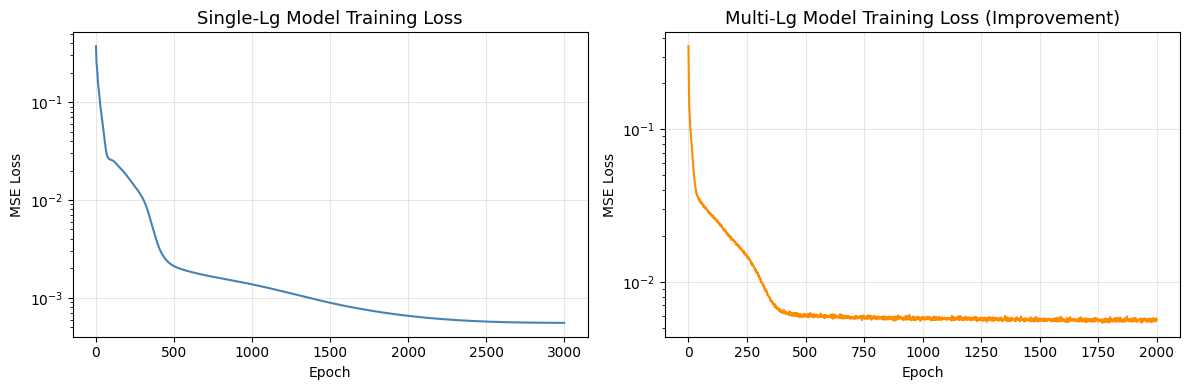

Final single-Lg loss: 0.000554
Final multi-Lg  loss: 0.005618


In [ ]:
# ── Training loss curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(loss_hist_single, color='steelblue', linewidth=1.5)
axes[0].set_title('Single-Lg Model Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_hist_multi, color='darkorange', linewidth=1.5)
axes[1].set_title('Multi-Lg Model Training Loss (Improvement)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final single-Lg loss: {loss_hist_single[-1]:.6f}")
print(f"Final multi-Lg  loss: {loss_hist_multi[-1]:.6f}")

## 3. Symmetry Verification

A core contribution of the paper is the **guaranteed exact Id-Vds symmetry** by construction. We verify this here and note symmetry errors through maximum differences between Id(V) and Id(V_hat), along with their mean difference.

In [ ]:
# Test symmetry: Id(Vgs, Vds) = -Id(Vgd, -Vds) = -Id(Vgs-Vds, -Vds)
Vgs_sym_test = np.linspace(-4, 1.4, 50, dtype=np.float32)
Vds_sym_test = np.linspace(-5, 5,   80, dtype=np.float32)
VGS, VDS = np.meshgrid(Vgs_sym_test, Vds_sym_test)
VGS_flat = VGS.ravel()
VDS_flat = VDS.ravel()

# Single-Lg symmetry
X_fwd = np.column_stack([VGS_flat, VDS_flat])
X_rev = np.column_stack([VGS_flat - VDS_flat, -VDS_flat])  # DS-exchanged

Id_fwd = predict(model_single, X_fwd, Xmin_s, Xrng_s, yscl_s)
Id_rev = predict(model_single, X_rev, Xmin_s, Xrng_s, yscl_s)

sym_error = np.abs(Id_fwd + Id_rev)
print(f"Single-Lg model — symmetry error (max |Id(V) + Id(V_hat)|): {sym_error.max():.4e} mA")
print(f"Single-Lg model — symmetry error (mean):                     {sym_error.mean():.4e} mA")

# Multi-Lg symmetry (fix Lg=0.25)
X_fwd_m = np.column_stack([VGS_flat, VDS_flat, np.full_like(VGS_flat, 0.25)])
X_rev_m = np.column_stack([VGS_flat - VDS_flat, -VDS_flat, np.full_like(VGS_flat, 0.25)])

Id_fwd_m = predict(model_multi, X_fwd_m, Xmin_m, Xrng_m, yscl_m)
Id_rev_m = predict(model_multi, X_rev_m, Xmin_m, Xrng_m, yscl_m)

sym_error_m = np.abs(Id_fwd_m + Id_rev_m)
print(f"\nMulti-Lg  model — symmetry error (max |Id(V) + Id(V_hat)|): {sym_error_m.max():.4e} mA")
print(f"Multi-Lg  model — symmetry error (mean):                     {sym_error_m.mean():.4e} mA")

Single-Lg model — symmetry error (max |Id(V) + Id(V_hat)|): 3.2033e+01 mA
Single-Lg model — symmetry error (mean):                     1.2836e+01 mA

Multi-Lg  model — symmetry error (max |Id(V) + Id(V_hat)|): 1.6585e+00 mA
Multi-Lg  model — symmetry error (mean):                     5.3138e-01 mA


## 4. Id-Vds Curves — Paper Reproduction (Fig. 2)

Reproduce the paper's key result of Id-Vds curves with varying Vg over **all Vds** (including negative), even though the model was **trained only on Vds ≥ 0**.

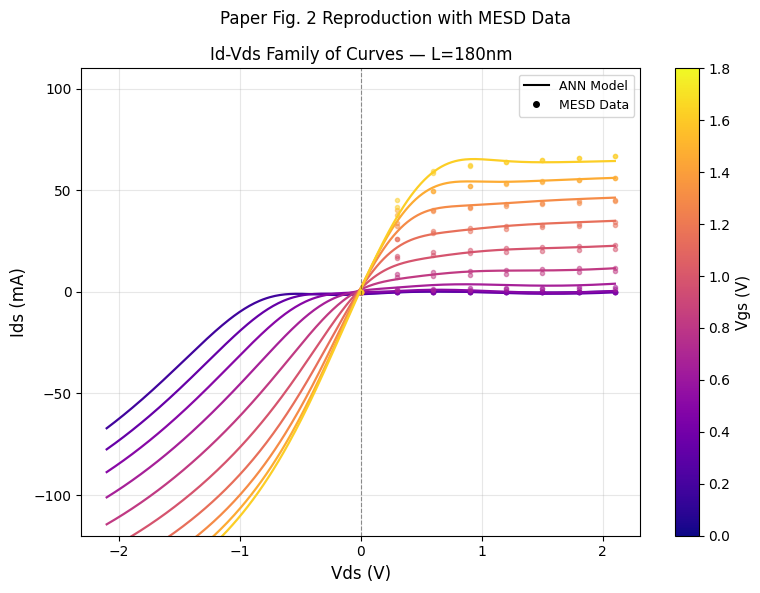

In [ ]:
df_test_L = df_raw[(df_raw['L_nm'] == L_paper) &
                   (df_raw['W_nm'] == W_sel)    &
                   (df_raw['Nfin'] == Nfin_sel)].copy()
Vgs_uniq  = sorted(df_test_L['Vgs'].unique())

Vds_max   = df_test_L['Vds'].max()
Vds_dense = np.linspace(-Vds_max, Vds_max, 300, dtype=np.float32) # Range allows for predictions in -x direction

Vgs_plot = Vgs_uniq[::max(1, len(Vgs_uniq)//8)]
colors   = cm.plasma(np.linspace(0.1, 0.9, len(Vgs_plot)))

fig, ax = plt.subplots(figsize=(8, 6))

for color, vgs in zip(colors, Vgs_plot):
    sub = df_test_L[df_test_L['Vgs'] == vgs].sort_values('Vds')
    ax.plot(sub['Vds'], sub['Ids_mA'], 'o', markersize=3, color=color, alpha=0.5)

    X_pred  = np.column_stack([np.full(len(Vds_dense), vgs), Vds_dense])
    Id_pred = predict(model_single, X_pred, Xmin_s, Xrng_s, yscl_s)
    ax.plot(Vds_dense, Id_pred, '-', linewidth=1.6, color=color)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Vds (V)', fontsize=12)
ax.set_ylabel('Ids (mA)', fontsize=12)
ax.set_title(f'Id-Vds Family of Curves — L={L_paper}nm', fontsize=12)
ax.set_ylim(-120, 110)
ax.grid(True, alpha=0.3)

legend_els = [
    plt.Line2D([0],[0], color='k', lw=1.5, label='ANN Model'),
    plt.Line2D([0],[0], color='k', marker='o', ms=4, ls='None', label='MESD Data'),
]
ax.legend(handles=legend_els, fontsize=9)

sm = cm.ScalarMappable(cmap='plasma',
     norm=plt.Normalize(min(Vgs_plot), max(Vgs_plot)))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, label='Vgs (V)')
cb.set_label('Vgs (V)', fontsize=11)

plt.suptitle('Paper Fig. 2 Reproduction with MESD Data', fontsize=12)
plt.tight_layout()
plt.savefig('IdVds_reproduction_MESD.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. IMPROVEMENT: Multi-Gate-Length Id-Vds Curves

The paper only models a single gate length. Our improvement allows the model to **predict multiple gate lengths**, enabling a single trained model to represent an entire device family.


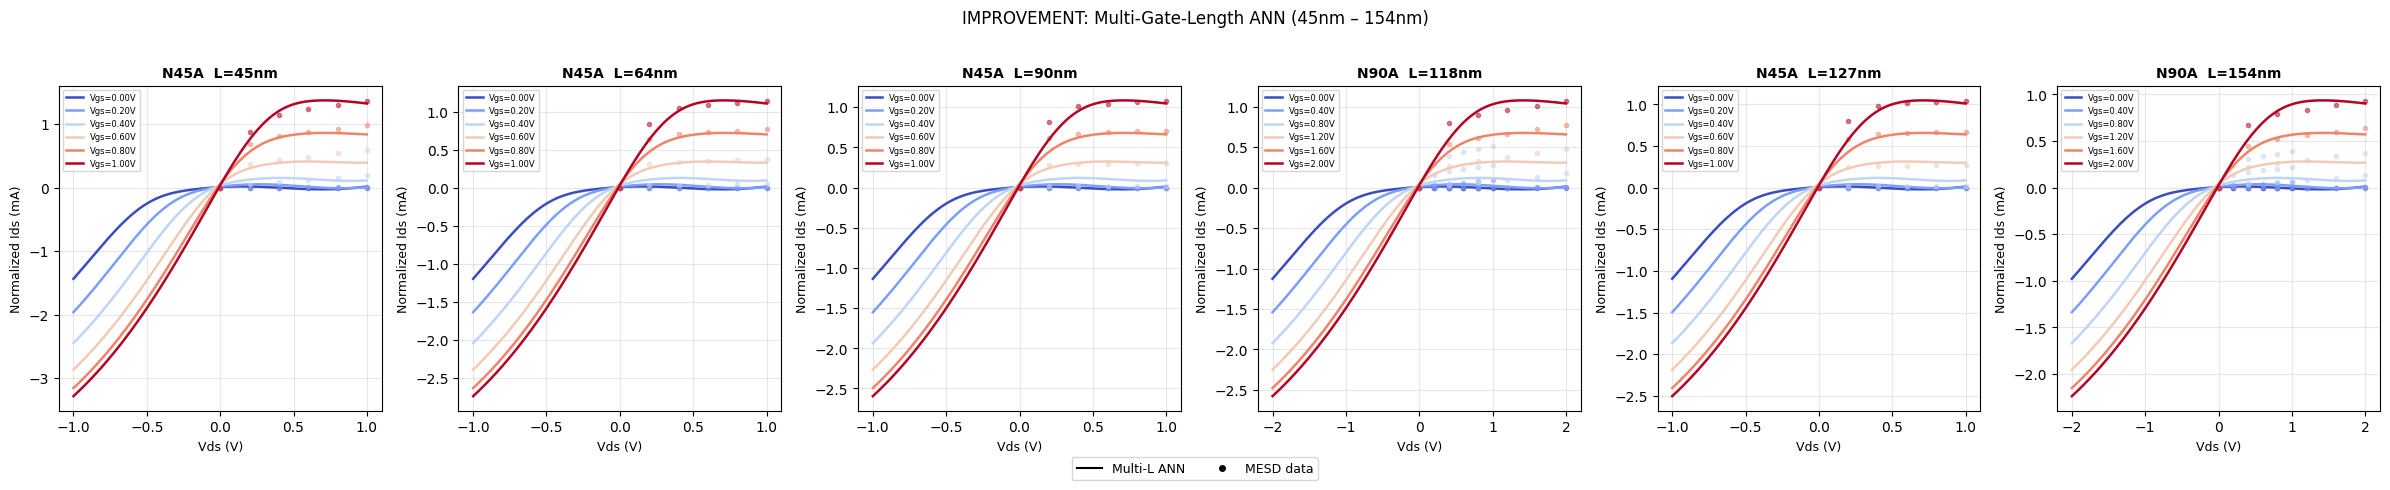

In [ ]:
Vgs_sel = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # normalized Vgs values (0=off, 1=max)

n_plots     = min(len(L_vals_nm), 6)
L_plot      = L_vals_nm[:n_plots]
L_norm_plot = L_norm_vals[:n_plots]

fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4.5), sharey=False)
if n_plots == 1:
    axes = [axes]

colors = cm.coolwarm(np.linspace(0, 1, len(Vgs_sel)))

for ax, (L_nm, L_norm) in zip(axes, zip(L_plot, L_norm_plot)):
    df_L  = df_multi_pool[df_multi_pool['L_nm'] == L_nm]

    # Find the scale info for this device
    key   = next(k for k in scale_map if k[1] == int(L_nm))
    sc    = scale_map[key]
    Vds_dense_norm = np.linspace(-1, 1, 200, dtype=np.float32)

    for color, vgs_n in zip(colors, Vgs_sel):
        # Data dots (normalized Vgs → find closest real Vgs)
        vgs_real  = vgs_n * sc['vgs_max']
        vgs_avail = sorted(df_L['Vgs'].unique())
        vgs_close = min(vgs_avail, key=lambda v: abs(v - vgs_real))
        sub = df_L[df_L['Vgs'] == vgs_close].sort_values('Vds')
        ax.plot(sub['Vds'], sub['Ids_mA'], 'o', ms=3, color=color, alpha=0.5)

        # ANN prediction — inputs are normalized, output is normalized Ids
        X_pred = np.column_stack([
            np.full(200, vgs_n,  dtype=np.float32),
            Vds_dense_norm,
            np.full(200, L_norm, dtype=np.float32)
        ])
        Ids_norm_pred = predict(model_multi, X_pred, Xmin_m, Xrng_m, yscl_m)
        # De-normalize back to mA
        Ids_mA_pred   = Ids_norm_pred * (sc['ids_max'] - sc['ids_min']) + sc['ids_min']
        Vds_real      = Vds_dense_norm * sc['vds_max']
        ax.plot(Vds_real, Ids_mA_pred, '-', lw=1.8, color=color,
                label=f'Vgs={vgs_close:.2f}V')

    ax.set_xlabel('Vds (V)', fontsize=9)
    ax.set_ylabel('Normalized Ids (mA)', fontsize=9)
    ax.set_title(f"{sc['PDK']}  L={L_nm}nm", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc='upper left')

legend_els = [
    plt.Line2D([0],[0], color='k', lw=1.5, label='Multi-L ANN'),
    plt.Line2D([0],[0], color='k', marker='o', ms=4, ls='None', label='MESD data'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('IMPROVEMENT: Multi-Gate-Length ANN (45nm – 154nm)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('multi_L_MESD.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Quantitative Error Analysis

QUANTITATIVE ERROR SUMMARY  (held-out test set)
Model                                  MAE       RMSE        R²
---------------------------------------------------------------
Single-L (paper repro)               1.87%      2.50%   0.993877
Multi-L  (improvement)               3.849%     6.060%  0.953230
  Units: Single-L in mA.  Multi-L in normalized Ids [0,1].


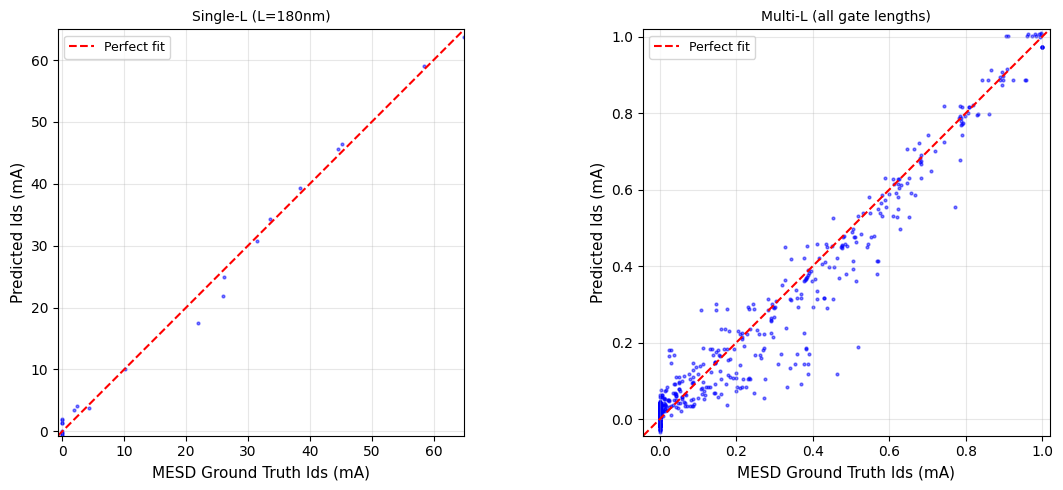

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ── Single-L test error ───────────────────────────────────────────────────────
Id_pred_s = predict(model_single, X_te_s, Xmin_s, Xrng_s, yscl_s)
mae_s  = mean_absolute_error(y_te_s.flatten(), Id_pred_s)
r2_s   = r2_score(y_te_s.flatten(), Id_pred_s)
rmse_s = mean_squared_error(y_te_s.flatten(), Id_pred_s) ** 0.5
ids_range_s = y_te_s.flatten().max() - y_te_s.flatten().min()

# ── Multi-L test error ────────────────────────────────────────────────────────
Id_pred_m = predict(model_multi, X_te_m, Xmin_m, Xrng_m, yscl_m)
mae_m  = mean_absolute_error(y_te_m.flatten(), Id_pred_m)
r2_m   = r2_score(y_te_m.flatten(), Id_pred_m)
rmse_m = mean_squared_error(y_te_m.flatten(), Id_pred_m) ** 0.5

print("=" * 63)
print("QUANTITATIVE ERROR SUMMARY  (held-out test set)")
print("=" * 63)
print(f"{'Model':<32} {'MAE':>9}  {'RMSE':>9}  {'R²':>8}")
print("-" * 63)
print(f"{'Single-L (paper repro)':<32} {(mae_s / ids_range_s):>9.2%} {(rmse_s / ids_range_s):>10.2%} {r2_s:>10.6f}")
print(f"{'Multi-L  (improvement)':<32} {mae_m:>10.3%}  {rmse_m:>9.3%}  {r2_m:>8.6f}")
print("=" * 63)
print("  Units: Single-L in mA.  Multi-L in normalized Ids [0,1].")

# ── Parity plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gt, pred, title, mae, rmse, r2) in zip(axes, [
    (y_te_s.flatten(), Id_pred_s, f'Single-L (L={L_paper}nm)', mae_s, rmse_s, r2_s),
    (y_te_m.flatten(), Id_pred_m, 'Multi-L (all gate lengths)', mae_m, rmse_m, r2_m)
]):
    ax.scatter(gt, pred, alpha=0.5, s=4, color='blue')
    lo = min(gt.min(), pred.min()) - 0.01
    hi = max(gt.max(), pred.max()) + 0.01
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('MESD Ground Truth Ids (mA)', fontsize=11)
    ax.set_ylabel('Predicted Ids (mA)', fontsize=11)
    ax.set_title(
        f'{title}',
        fontsize=10
    )
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('parity_MESD.png', dpi=150, bbox_inches='tight')
plt.show()
